# Phase 6: Deployment, charts for the story

The charts below are the same ones shown in the Streamlit app. They come from `charts.py`, and the numbers from `analysis.py`, so the notebook and the app always agree.


In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# make analysis.py and charts.py importable whether this notebook is in notebooks/ or the repo root
root = Path.cwd()
if not (root / "analysis.py").exists():
    root = root.parent
sys.path.insert(0, str(root))

import analysis as A
import charts as C

joined = A.load_joined(root / "data" / "cleaned" / "joined.csv")
ctry = A.country_table(joined)
print(joined.shape, "country-year rows;", len(ctry), "countries in the country table")

(10562, 21) country-year rows; 203 countries in the country table


## Chart 1: more spending, more students enrolled

**Why this chart:** it answers the main question directly. Country-years are grouped into 8 spending levels, and the average enrolment at each level is plotted for primary, secondary and tertiary.

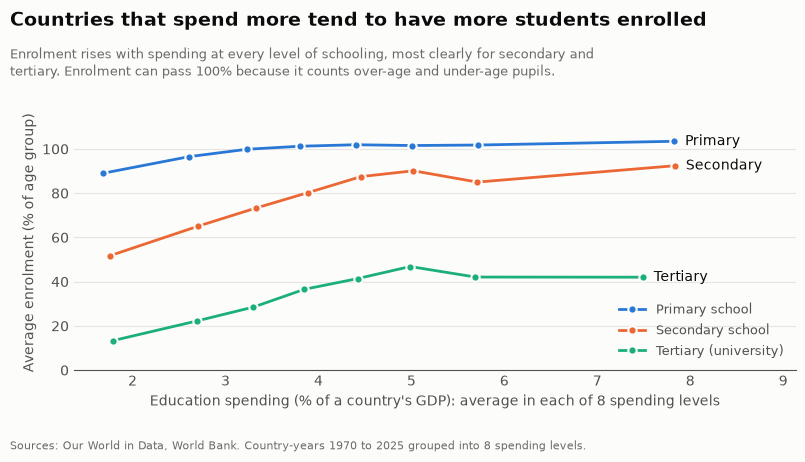

In [2]:
by_spending = A.enrolment_by_spending(joined)
C.fig_enrolment_by_spending(by_spending)
plt.show()

**What it shows:** The enrolment rises with spending at all three levels across all income groups. Primary is already high almost everywhere, so it has the least room to rise.

## Chart 2: where the link is clearest

**Why this chart:** a rich country and a poor country are not comparable. Here each country is compared only with others in its own income group.

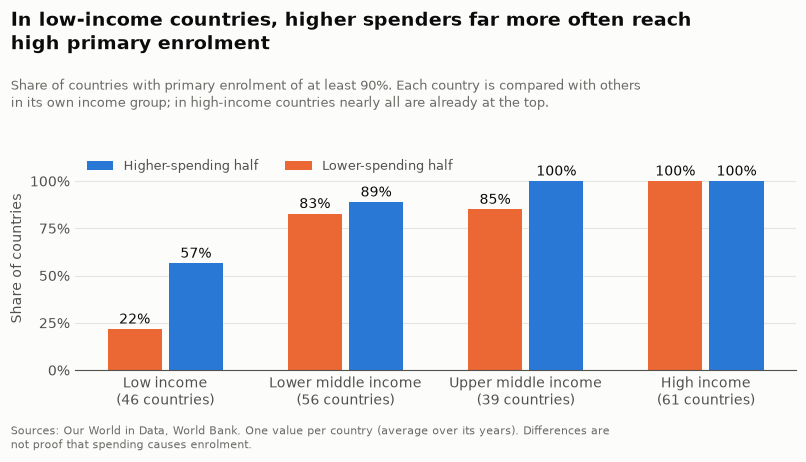

,income,spend_group,share,countries
0,Low,high,0.565217,23
1,Low,low,0.217391,23
2,Lower middle,high,0.888889,27
3,Lower middle,low,0.827586,29
4,Upper middle,high,1.000000,19
5,Upper middle,low,0.850000,20
6,High,high,1.000000,30
7,High,low,1.000000,31


In [3]:
by_income = A.high_enrolment_by_income(ctry)
C.fig_high_enrolment_by_income(by_income)
plt.show()
by_income

**What it shows:** the gap between higher and lower spenders is largest in low-income countries, where many are still below 90% primary enrolment.

## Chart 3: is it just wealth?

**Why this chart:** the obvious objection is that rich countries spend more and enrol more. Blue is the link with spending alone; orange is the link after removing the effect of GDP per capita.

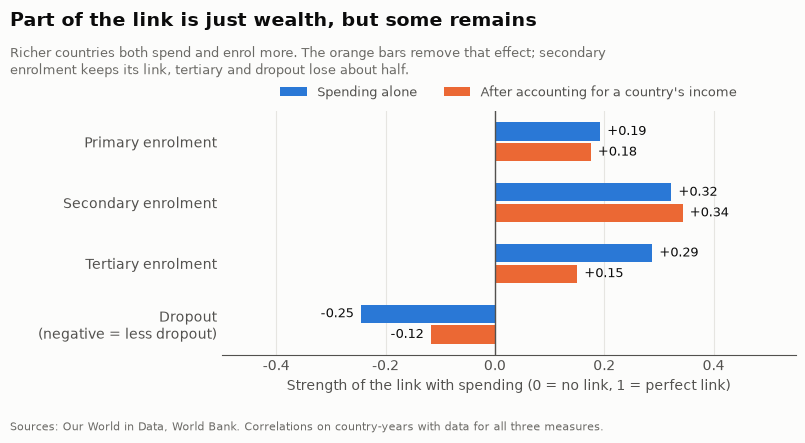

,outcome,rows,spending alone,after accounting for income
0,Primary school enrolment,3206,0.193,0.176
1,Secondary school enrolment,2801,0.323,0.344
2,Tertiary (university) enrolment,2580,0.288,0.151
3,Pupils who do not reach the last primary grade,1986,-0.246,-0.118


In [4]:
wealth = A.wealth_check(joined)
C.fig_wealth_check(wealth)
plt.show()
wealth.drop(columns="key").round(3)

## Chart 4: country by country

Change `outcome` to `'primary'`, `'tertiary'` or `'dropout'` to see the others.

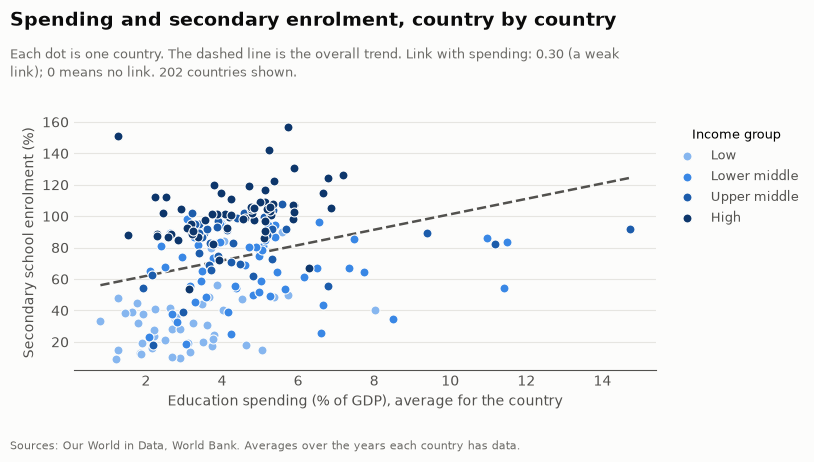

In [5]:
C.fig_country_scatter(ctry, outcome="secondary")
plt.show()

## Chart 5: dropout

**Why this chart:** dropout is the weakest result, so we show every country rather than only an average.

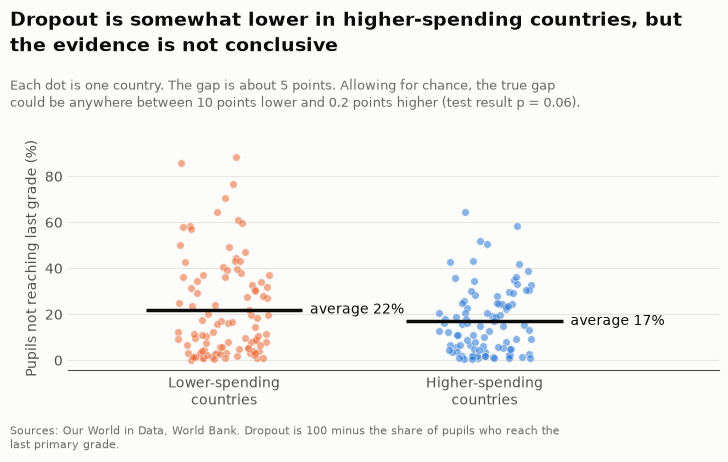

In [6]:
w = A.welch(ctry, "dropout")
C.fig_dropout_groups(w)
plt.show()

## Is the evidence strong? The four tests, in plain language

In [7]:
A.run_tests(ctry)

,Question,Test,Statistic,p-value,What we saw,Reading
0,Do high-spending countries lose fewer pupils b...,Welch t-test,t = -1.91,0.057509,About 5 points less dropout in high-spending c...,"Suggestive, not conclusive"
1,Are high-spending countries more likely to rea...,Two-proportion Z-test,z = 2.18,0.029249,87% of high spenders against 75% of low spenders,Unlikely to be chance (p below 0.05)
2,"Does secondary enrolment differ between low, m...",ANOVA (F-test),F = 2.74,0.067004,"Averages of 67%, 72% and 80%","Suggestive, not conclusive"
3,Is reaching 90% primary enrolment independent ...,Chi-square test,chi-square = 6.67,0.035593,"Share reaching 90%: low 77%, middle 75%, high 91%",Unlikely to be chance (p below 0.05)


## Deploying the app

1. Run locally: `uv run streamlit run app.py`
2. Push the repo to GitHub (include `data/cleaned/joined.csv` and `uv.lock`).
3. On share.streamlit.io choose the repo, branch `main`, main file `app.py`, then Deploy.
4. Paste the live URL into the README and into the slides.